# What proportion of Wikipedia articles include mentions of guitar?

In [37]:
import requests
import time
import pandas as pd
import random
import seaborn

url = "https://en.wikipedia.org/w/api.php"

headers = {
    'User-Agent': 'StatisticsEducationBot/1.0 (Statistics Class Project; educational use)'
}

In [34]:
session = requests.Session()

hitcnt = 0
tot = 100

for i in range(tot):

    # 1. Get a random page ID
    rand_params = {
        "action": "query",
        "list": "random",
        "rnnamespace": 0,   # main/article space only
        "rnlimit": 1,
        "format": "json"
    }

    rand_resp = session.get(url=url, params=rand_params, headers=headers)
    rand_data = rand_resp.json()

    page_id = rand_data["query"]["random"][0]["id"]

    # 2. Fetch the full article extract
    content_params = {
        "action": "query",
        "pageids": page_id,
        "prop": "extracts",
        "explaintext": True,
        "exlimit": "max",
        "format": "json"
    }

    content_resp = session.get(url=url, params=content_params, headers=headers)
    content_data = content_resp.json()

    pages = content_data["query"]["pages"]
    page = pages[str(page_id)]
    content = page.get("extract", "")

    # Check for guitar keyword
    if "guitar" in content.lower():
        hitcnt += 1

p = hitcnt / tot
print(str(p * 100)+ "%")

5.0%


In [43]:
means = []
for i in range(100):
    hitcnt = 0
    for j in range(10):
        print((i,j), end ="\r", flush = True)
    
        # 1. Get a random page ID
        rand_params = {
            "action": "query",
            "list": "random",
            "rnnamespace": 0,   # main/article space only
            "rnlimit": 1,
            "format": "json"
        }
    
        rand_resp = session.get(url=url, params=rand_params, headers=headers)
        rand_data = rand_resp.json()
    
        page_id = rand_data["query"]["random"][0]["id"]
    
        # 2. Fetch the full article extract
        content_params = {
            "action": "query",
            "pageids": page_id,
            "prop": "extracts",
            "explaintext": True,
            "exlimit": "max",
            "format": "json"
        }
    
        content_resp = session.get(url=url, params=content_params, headers=headers)
        content_data = content_resp.json()
    
        pages = content_data["query"]["pages"]
        page = pages[str(page_id)]
        content = page.get("extract", "")
    
        # Check for guitar keyword
        if "guitar" in content.lower():
            hitcnt += 1
    
    p = hitcnt / 10
    means.append(p)

(99, 9)

/opt/conda/envs/anaconda-2024.02-py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: ylabel='Count'>

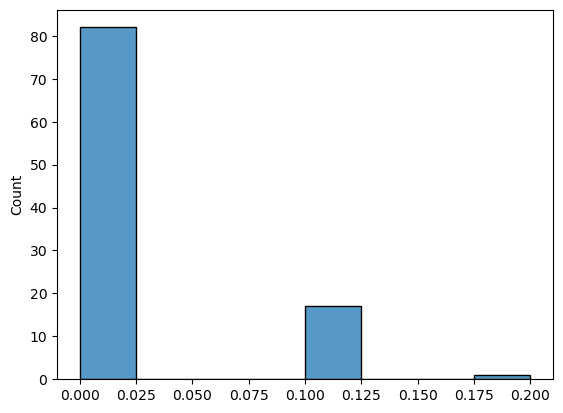

In [48]:
seaborn.histplot(means)

In [52]:
mean = 0
for p in means:
    mean+=p
mean /= len(means)
str(mean*100)+"%"

'1.9000000000000004%'

Standard Error = 0.0432, Margin of Error = 0.084, Confidence Interval = (-0.067, 0.1036)

The distribution does not look very normal. The answer I achieved was 1.9% of articles on Wikipedia included the word guitar, with a margin of error of 8.4% and a confidence interval of (-0.067, 0.1036). Because of the large margin of error, these results should not be trusted, so more data would help improve the reliability of this.